# Figure 7 — CellChat chord diagrams (FIB4 ↔ Basal keratinocytes)

Differential cell–cell communication between Fibroblast 4 and basal keratinocytes,
Expanded vs Control.

Panels:

- **a**: Upregulated signaling interactions EXP vs CTRL, Basal keratinocytes → FIB4
- **b**: Downregulated signaling interactions EXP vs CTRL, Basal keratinocytes → FIB4
- **c**: Upregulated signaling interactions EXP vs CTRL, FIB4 → Basal keratinocytes
- **d**: Downregulated signaling interactions EXP vs CTRL, FIB4 → Basal keratinocytes

Inputs (preprocessed upstream):
- `cellchat_control_sub_processed.rds` — CellChat object, Control condition, subset to {FIB4, basal kera}
- `cellchat_expanded_sub_processed.rds` — CellChat object, Expanded condition, same subset

If you don't have those processed objects yet, run the **Section 0 — Build CellChat objects**
cell once (it loads the base CellChat objects, subsets to the two cell types, and runs the
full pipeline). Subsequent runs of the notebook can skip that section.

**Display renames** (matching the manuscript axis labels):
- `keratinocytes_basal` → `Basal keratinocytes`
- `Fibroblast 4`        → `FIB4`

These are applied to `cellchat@idents` *levels* only, before plotting. The underlying
cell-level annotations stay untouched.

## Imports

In [3]:
suppressPackageStartupMessages({
    library(Seurat)
    library(CellChat)
    library(patchwork)
    library(future)
})
options(stringsAsFactors = FALSE)

# Output directory for the saved figure SVGs (matches the convention used by figs 1, 3, 6)
out_dir <- 'manuscript_figures/figure_7'
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

## Section 0 — Build CellChat objects (run once, then skip)

Subsets the base CellChat objects (Control / Expanded) to `{Fibroblast 4, keratinocytes_basal}`
and runs the standard CellChat pipeline. Saves the processed objects so subsequent
notebook runs can skip straight to Section 1.

Set `RUN_BUILD <- TRUE` to execute this block. Default is `FALSE` so re-running the
whole notebook doesn't redo the expensive pipeline.

In [ ]:
RUN_BUILD <- FALSE   # set to TRUE on first run

if (RUN_BUILD) {
    target_groups <- c('Fibroblast 4', 'keratinocytes_basal')

    subset_cellchat_groups <- function(cellchat, groups) {
        meta      <- cellchat@meta
        labels    <- as.character(cellchat@idents)
        cells.use <- rownames(meta)[labels %in% groups]
        if (length(cells.use) == 0) stop('No cells found for requested groups.')

        cellchat@data <- cellchat@data[, cells.use, drop = FALSE]
        cellchat@meta <- meta[cells.use, , drop = FALSE]

        if (!is.null(dim(cellchat@data.signaling))) {
            cols.keep <- intersect(colnames(cellchat@data.signaling), cells.use)
            cellchat@data.signaling <- cellchat@data.signaling[, cols.keep, drop = FALSE]
        }

        new_labels      <- labels[labels %in% groups]
        cellchat@idents <- droplevels(factor(new_labels, levels = groups))

        if (!is.null(cellchat@var.features)) {
            cellchat@var.features <- intersect(cellchat@var.features, rownames(cellchat@data))
        }

        cellchat@LR   <- list()
        cellchat@net  <- list(size = as.numeric(table(cellchat@idents)))
        names(cellchat@net$size) <- names(table(cellchat@idents))
        cellchat@netP <- list()

        cellchat
    }

    # Load base objects
    cellchat_expanded <- readRDS('../../data/skin_expansion_data/cellchat_expanded_clean_base.rds')
    cellchat_control  <- readRDS('../../data/skin_expansion_data/cellchat_control_clean_base.rds')

    # Subset to target groups
    cellchat_control_sub  <- subset_cellchat_groups(cellchat_control,  target_groups)
    cellchat_expanded_sub <- subset_cellchat_groups(cellchat_expanded, target_groups)

    # Parallel pipeline
    options(future.globals.maxSize = 60 * 1024^3)
    future::plan('multisession', workers = 12)

    run_pipeline <- function(cc) {
        cc <- subsetData(cc)
        cc <- identifyOverExpressedGenes(cc)
        cc <- identifyOverExpressedInteractions(cc)
        cc <- computeCommunProb(cc, type = 'triMean')
        cc <- filterCommunication(cc, min.cells = 10)
        cc <- computeCommunProbPathway(cc)
        cc <- aggregateNet(cc)
        cc <- netAnalysis_computeCentrality(cc)
        cc
    }
    cellchat_control_sub  <- run_pipeline(cellchat_control_sub)
    cellchat_expanded_sub <- run_pipeline(cellchat_expanded_sub)

    saveRDS(cellchat_control_sub,  '../../results/cellchat_control_sub_processed.rds')
    saveRDS(cellchat_expanded_sub, '../../results/cellchat_expanded_sub_processed.rds')
    message('Saved processed objects to ../../results/')
}

## Section 1 — Load pre-computed CellChat objects

In [2]:
cellchat_control_sub  <- readRDS("skin_expansion_data/cellchat_control_fibro4_kera_sub.rds")
cellchat_expanded_sub <- readRDS("skin_expansion_data/cellchat_expanded_fibro4_kera_sub.rds")
cat('Control:  '); print(levels(cellchat_control_sub@idents))
cat('Expanded: '); print(levels(cellchat_expanded_sub@idents))

Control:  [1] "Fibroblast 4"        "keratinocytes_basal"
Expanded: [1] "Fibroblast 4"        "keratinocytes_basal"


## Section 2 — Merge + identify differentially expressed LR pairs (EXP vs CTRL)

Standard CellChat differential workflow: merge the two condition objects, identify
over-expressed genes flagging Expanded as the positive dataset, then map DE results onto
the LR network and split into up- vs down-regulated subsets.

**Note**: this runs on the *original* `@idents` labels (`Fibroblast 4`, `keratinocytes_basal`).
Display renaming happens after this section — renaming before merge breaks the joint-label
lookup that `subsetCommunication` uses, returning zero significant interactions.

In [4]:
object.list <- list(Control = cellchat_control_sub, Expanded = cellchat_expanded_sub)
cellchat    <- mergeCellChat(object.list, add.names = names(object.list))

pos.dataset   <- 'Expanded'
features.name <- paste0(pos.dataset, '.merged')

cellchat <- identifyOverExpressedGenes(
    cellchat,
    group.dataset     = 'datasets',
    pos.dataset       = pos.dataset,
    features.name     = features.name,
    only.pos          = FALSE,
    thresh.pc         = 0.1,
    thresh.fc         = 0.05,
    thresh.p          = 0.05,
    group.DE.combined = FALSE
)
net      <- netMappingDEG(cellchat, features.name = features.name, variable.all = TRUE)
net.up   <- subsetCommunication(cellchat, net = net, datasets = 'Expanded',
                                ligand.logFC =  0.05, receptor.logFC = NULL)
net.down <- subsetCommunication(cellchat, net = net, datasets = 'Control',
                                ligand.logFC = -0.05, receptor.logFC = NULL)

# Source-data CSVs (useful for supp / reviewer requests)
write.csv(net.up,   file.path(out_dir, 'fig7_net_up_for_chord.csv'),   row.names = FALSE)
write.csv(net.down, file.path(out_dir, 'fig7_net_down_for_chord.csv'), row.names = FALSE)

cat('net.up:   ', nrow(net.up),   ' DE LR pairs\n')
cat('net.down: ', nrow(net.down), ' DE LR pairs\n')

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.

Use the joint cell labels from the merged CellChat object



net.up:    115  DE LR pairs
net.down:  105  DE LR pairs


## Display renames (post-merge)

Now that `mergeCellChat` and `subsetCommunication` are done, rename the factor levels in
`@idents` so the published display labels (`Basal keratinocytes`, `FIB4`) appear in the
chord legends/tick marks.

The renamed objects (`*_disp`) are used for plotting only. We don't overwrite the originals
in case any further CellChat operations need the originals' labels.

**Why post-merge**: renaming before `mergeCellChat` breaks the joint cell-label index used
by `subsetCommunication`, causing it to return zero interactions even though the underlying
DE results are intact. The `@net` slot stores edges keyed by the original idents at the
time `aggregateNet` was run; renaming the factor levels desynchronises the keys.

In [5]:
rename_idents_levels <- function(cc, mapping) {
    lvls <- levels(cc@idents)
    for (old in names(mapping)) {
        lvls[lvls == old] <- mapping[[old]]
    }
    levels(cc@idents) <- lvls
    cc
}

display_mapping <- list(
    'keratinocytes_basal' = 'Basal keratinocytes',
    'Fibroblast 4'        = 'FIB4'
)

# Plot-only copies (originals stay intact)
cellchat_control_disp  <- rename_idents_levels(cellchat_control_sub,  display_mapping)
cellchat_expanded_disp <- rename_idents_levels(cellchat_expanded_sub, display_mapping)

# Re-pack object.list with the renamed copies so the panel cells below use these
object.list <- list(Control = cellchat_control_disp, Expanded = cellchat_expanded_disp)

# Also rename the source/target columns of net.up / net.down so that sources.use /
# targets.use filters in netVisual_chord_gene match the renamed labels.
rename_net_labels <- function(net_df, mapping) {
    for (old in names(mapping)) {
        new <- mapping[[old]]
        if ('source' %in% colnames(net_df)) {
            net_df$source <- ifelse(as.character(net_df$source) == old, new,
                                    as.character(net_df$source))
        }
        if ('target' %in% colnames(net_df)) {
            net_df$target <- ifelse(as.character(net_df$target) == old, new,
                                    as.character(net_df$target))
        }
    }
    net_df
}
net.up   <- rename_net_labels(net.up,   display_mapping)
net.down <- rename_net_labels(net.down, display_mapping)

# Verify
cat('Control:  '); print(levels(cellchat_control_disp@idents))
cat('Expanded: '); print(levels(cellchat_expanded_disp@idents))
cat('net.up sources:   '); print(unique(net.up$source))
cat('net.up targets:   '); print(unique(net.up$target))
cat('net.down sources: '); print(unique(net.down$source))
cat('net.down targets: '); print(unique(net.down$target))

Control:  [1] "FIB4"                "Basal keratinocytes"
Expanded: [1] "FIB4"                "Basal keratinocytes"
net.up sources:   [1] "FIB4"                "Basal keratinocytes"
net.up targets:   [1] "FIB4"                "Basal keratinocytes"
net.down sources: [1] "FIB4"                "Basal keratinocytes"
net.down targets: [1] "FIB4"                "Basal keratinocytes"


## Colour palette

Lavender for basal keratinocytes, red for FIB4 — matches the published legend swatches.
Names must exactly match the (renamed) levels of `@idents` for `color.use` to take effect.

In [6]:
color_use <- c(
    'Basal keratinocytes' = '#C6B0D6',   # lavender
    'FIB4'                = '#E62E2E'    # red
)

## Section 3 — Draw chord diagrams (panels a–d)

Helper: wraps `netVisual_chord_gene` with the shared style (color_use, title font, label size)
and saves the result as an SVG.

**Direction convention**:
- Panels a, b: `sources.use = Basal keratinocytes`, `targets.use = FIB4`
- Panels c, d: `sources.use = FIB4`, `targets.use = Basal keratinocytes`

**Object selection**:
- Up-regulated (a, c): plotted on the `Expanded` object (object.list[[2]])
- Down-regulated (b, d): plotted on the `Control` object (object.list[[1]])

In [7]:
draw_chord <- function(cc, net_df, sources, targets, title, out_svg,
                       width = 8, height = 8) {
    svg(file.path(out_dir, out_svg), width = width, height = height, bg = 'white')
    par(bg = 'white')
    netVisual_chord_gene(
        cc,
        sources.use = sources,
        targets.use = targets,
        slot.name   = 'net',
        net         = net_df,
        color.use   = color_use,
        lab.cex     = 0.8,
        small.gap   = 3.5,
        title.name  = title
    )
    dev.off()
    message('Saved: ', file.path(out_dir, out_svg))
}

### Panel a — Upregulated EXP vs CTRL, Basal keratinocytes → FIB4

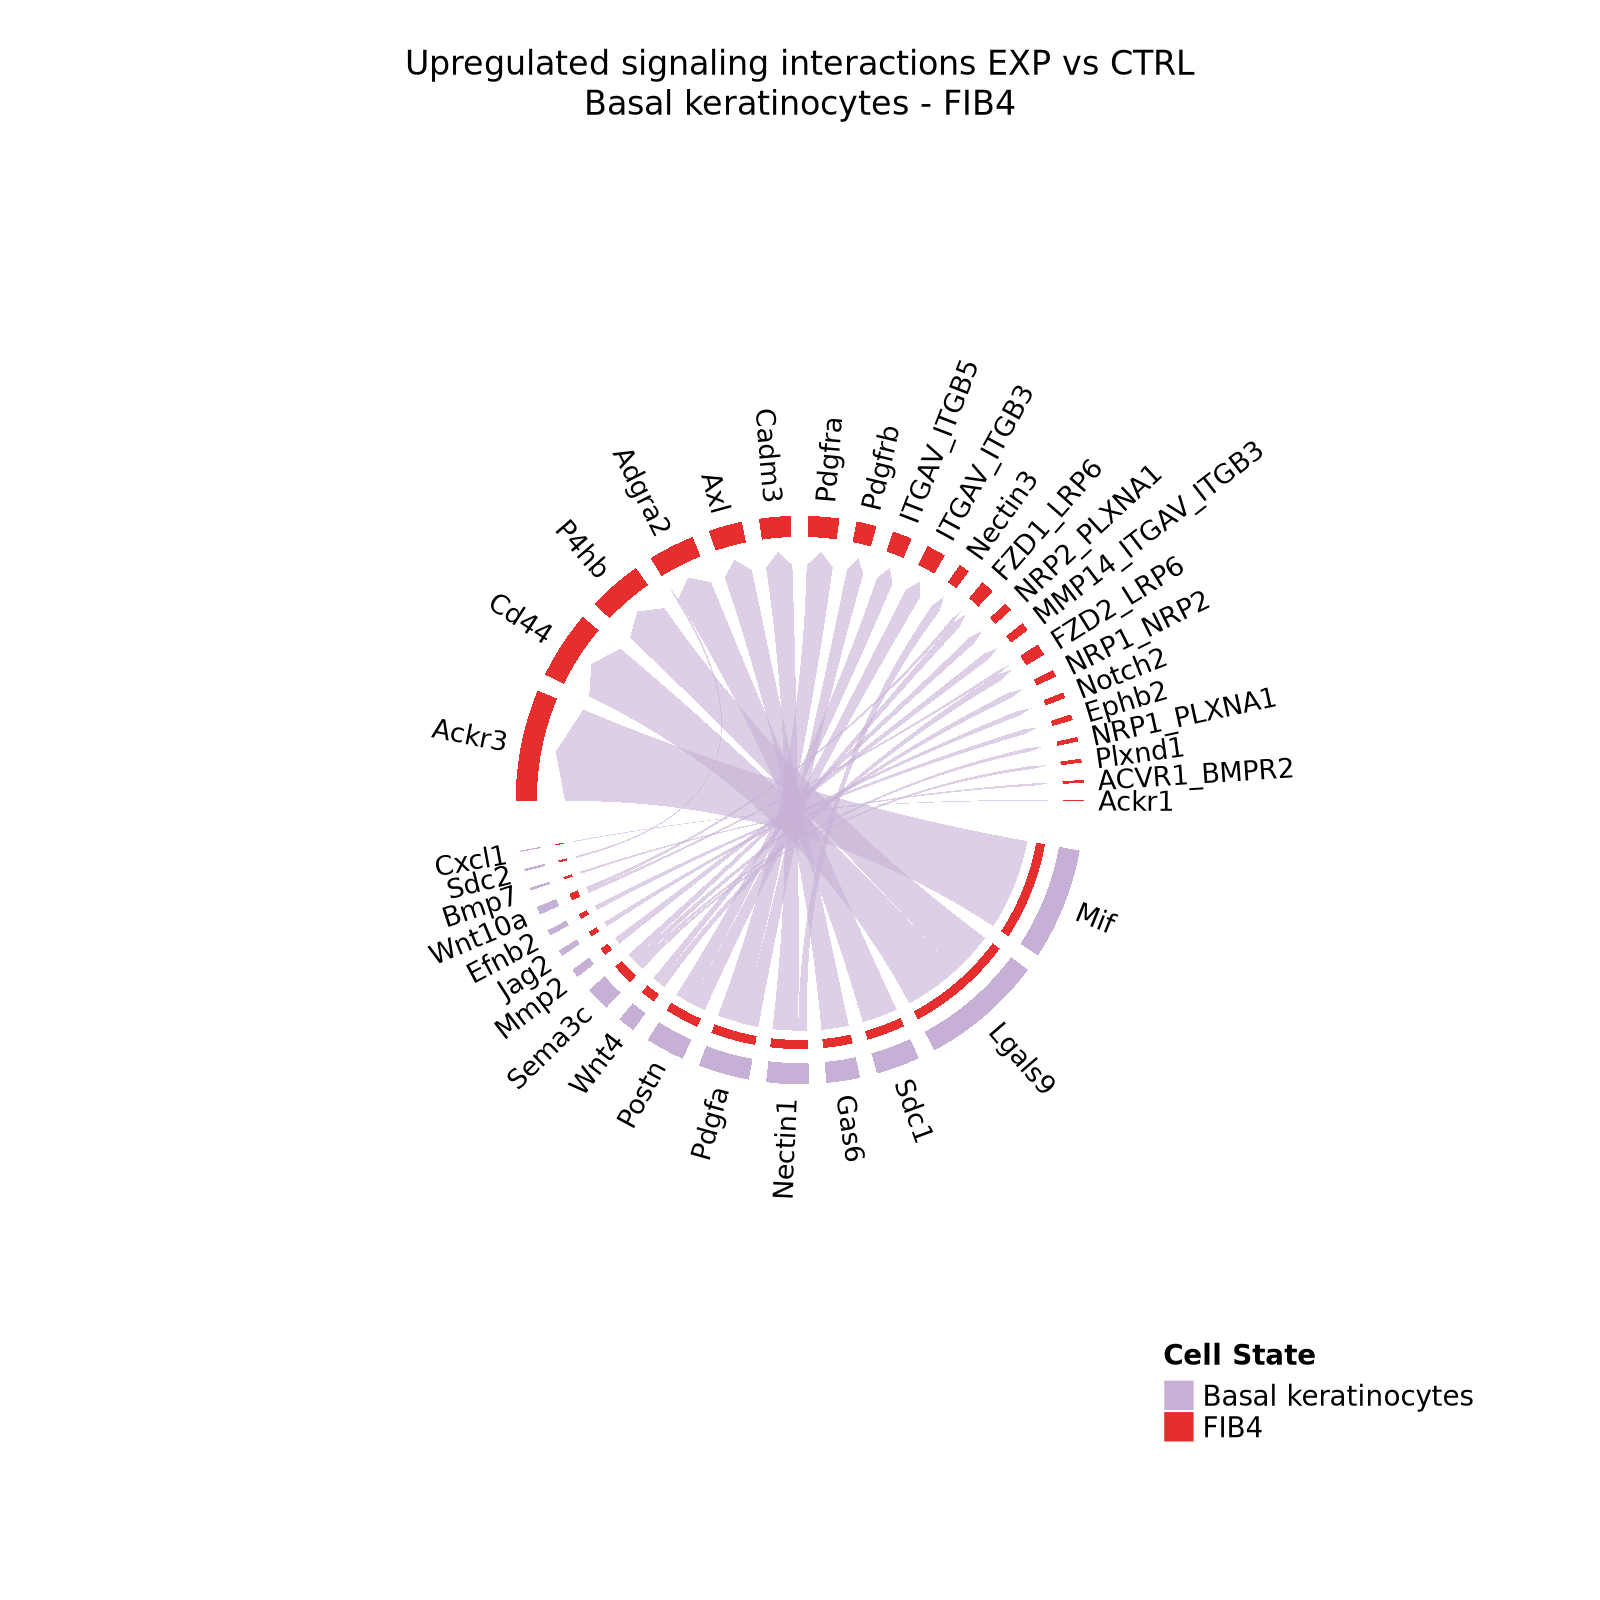

Saved: manuscript_figures/figure_7/fig7a_upregulated_basal_to_fib4.svg



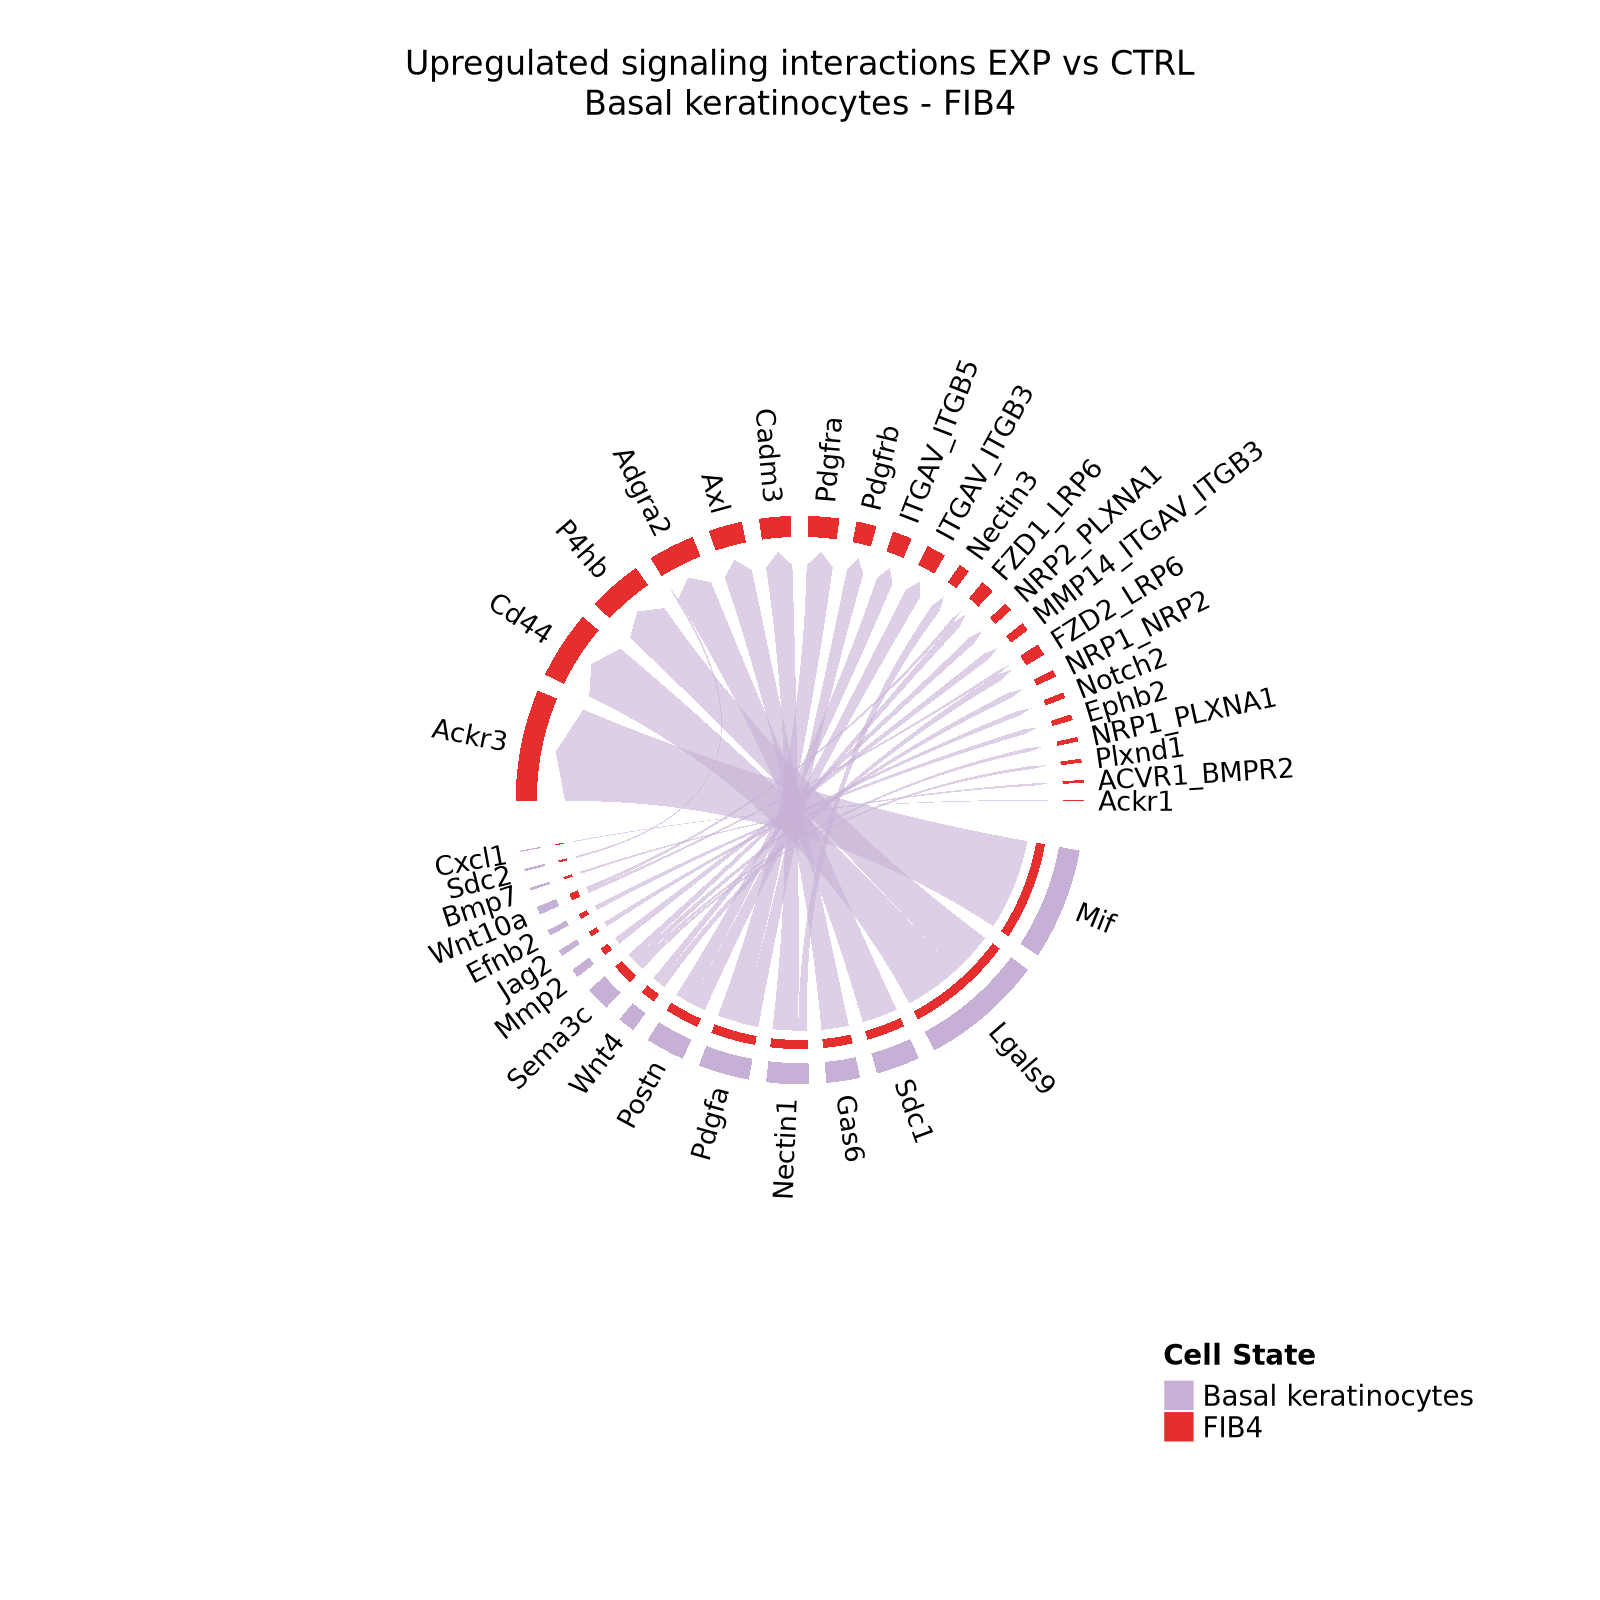

In [8]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

title_a <- 'Upregulated signaling interactions EXP vs CTRL\nBasal keratinocytes - FIB4'

# Inline preview
par(bg = 'white')
netVisual_chord_gene(
    object.list[['Expanded']],
    sources.use = 'Basal keratinocytes',
    targets.use = 'FIB4',
    slot.name   = 'net',
    net         = net.up,
    color.use   = color_use,
    lab.cex     = 0.8,
    small.gap   = 3.5,
    title.name  = title_a
)

# SVG save
draw_chord(
    cc        = object.list[['Expanded']],
    net_df    = net.up,
    sources   = 'Basal keratinocytes',
    targets   = 'FIB4',
    title     = title_a,
    out_svg   = 'fig7a_upregulated_basal_to_fib4.svg'
)

### Panel b — Downregulated EXP vs CTRL, Basal keratinocytes → FIB4

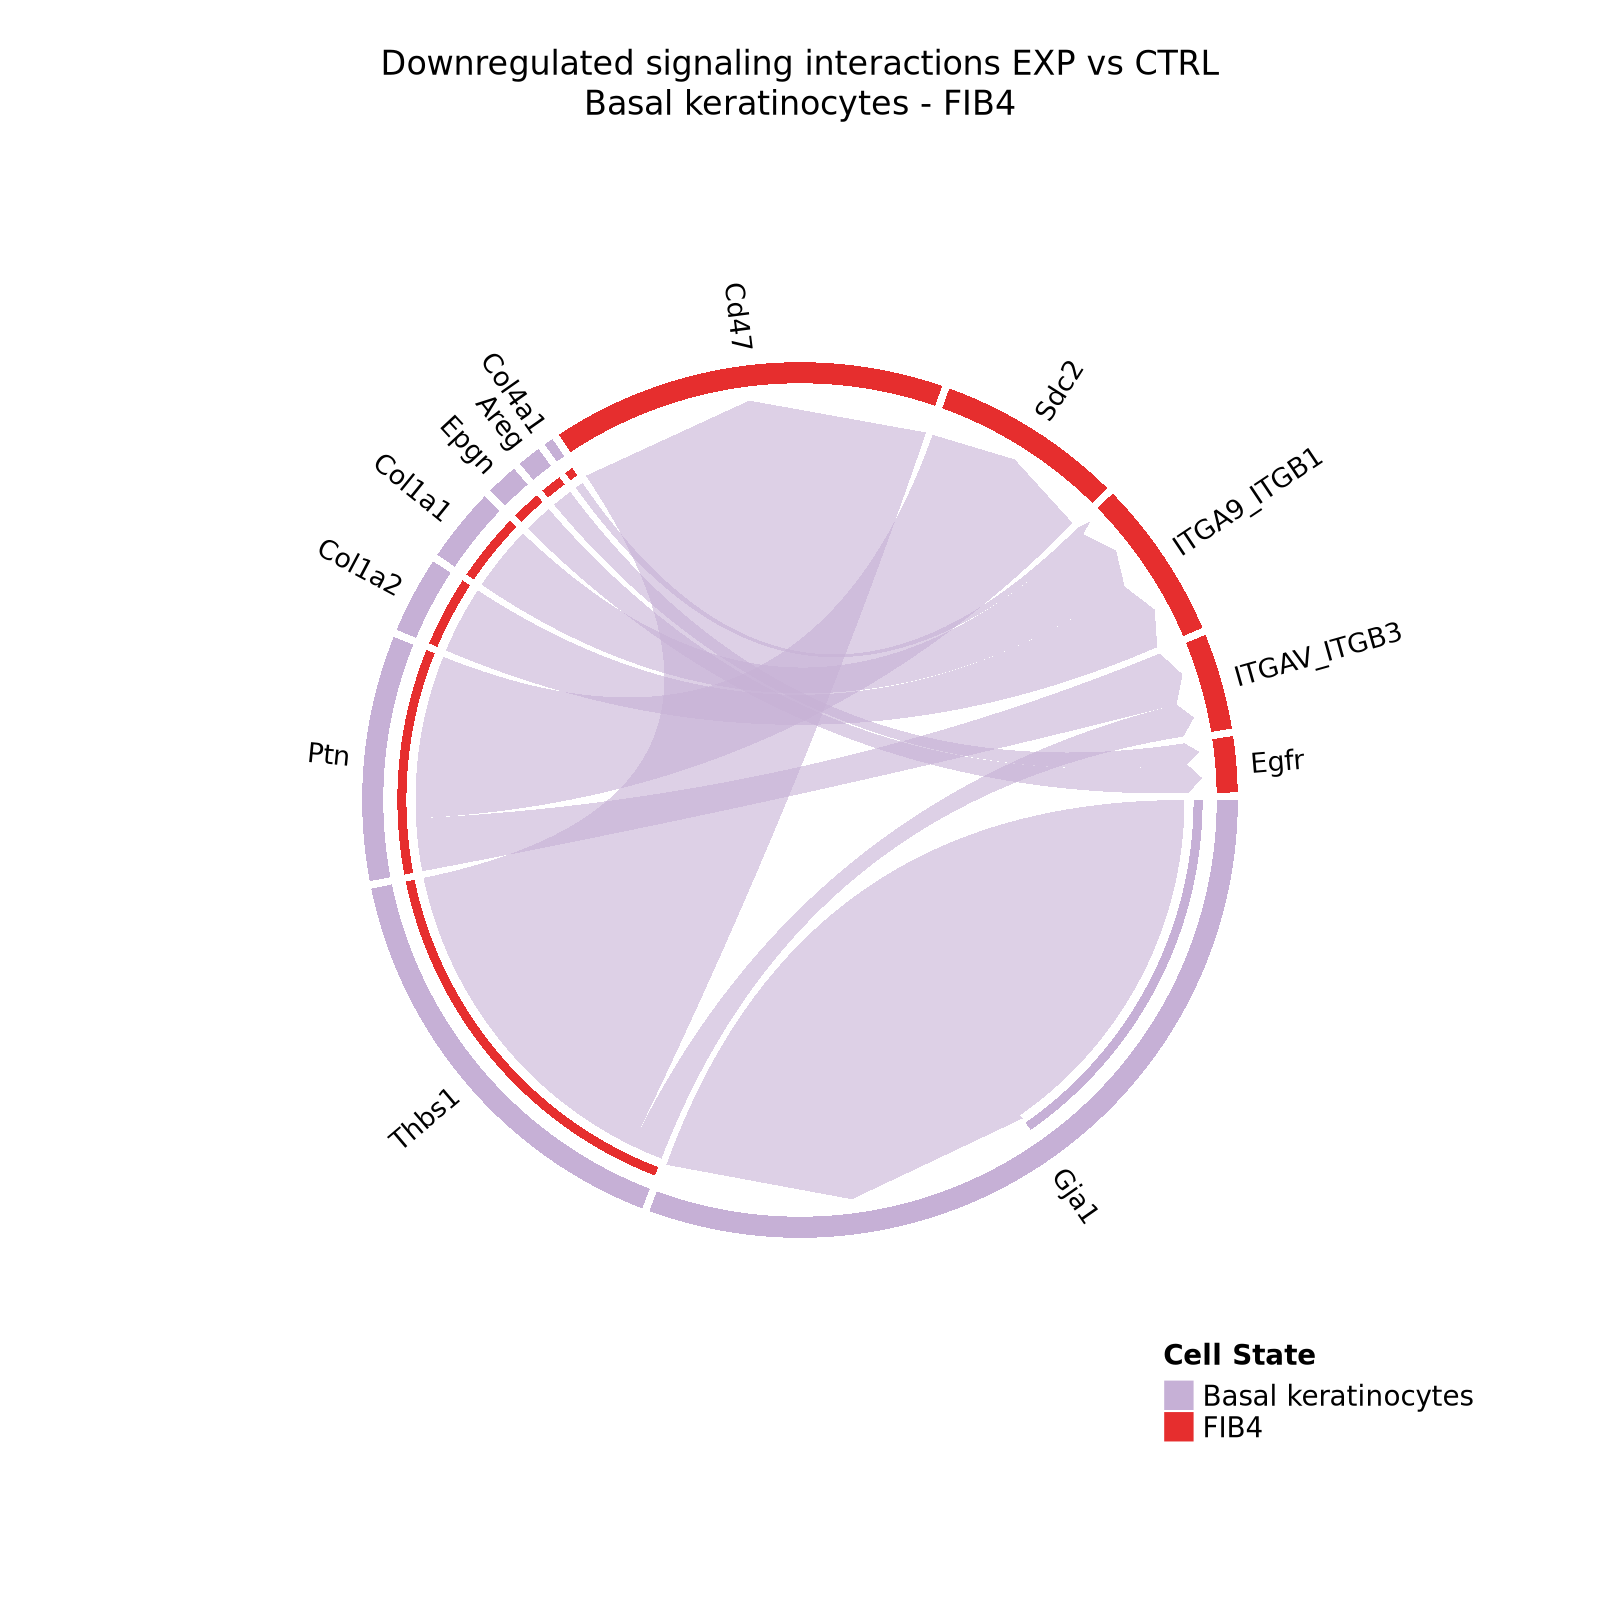

Saved: manuscript_figures/figure_7/fig7b_downregulated_basal_to_fib4.svg



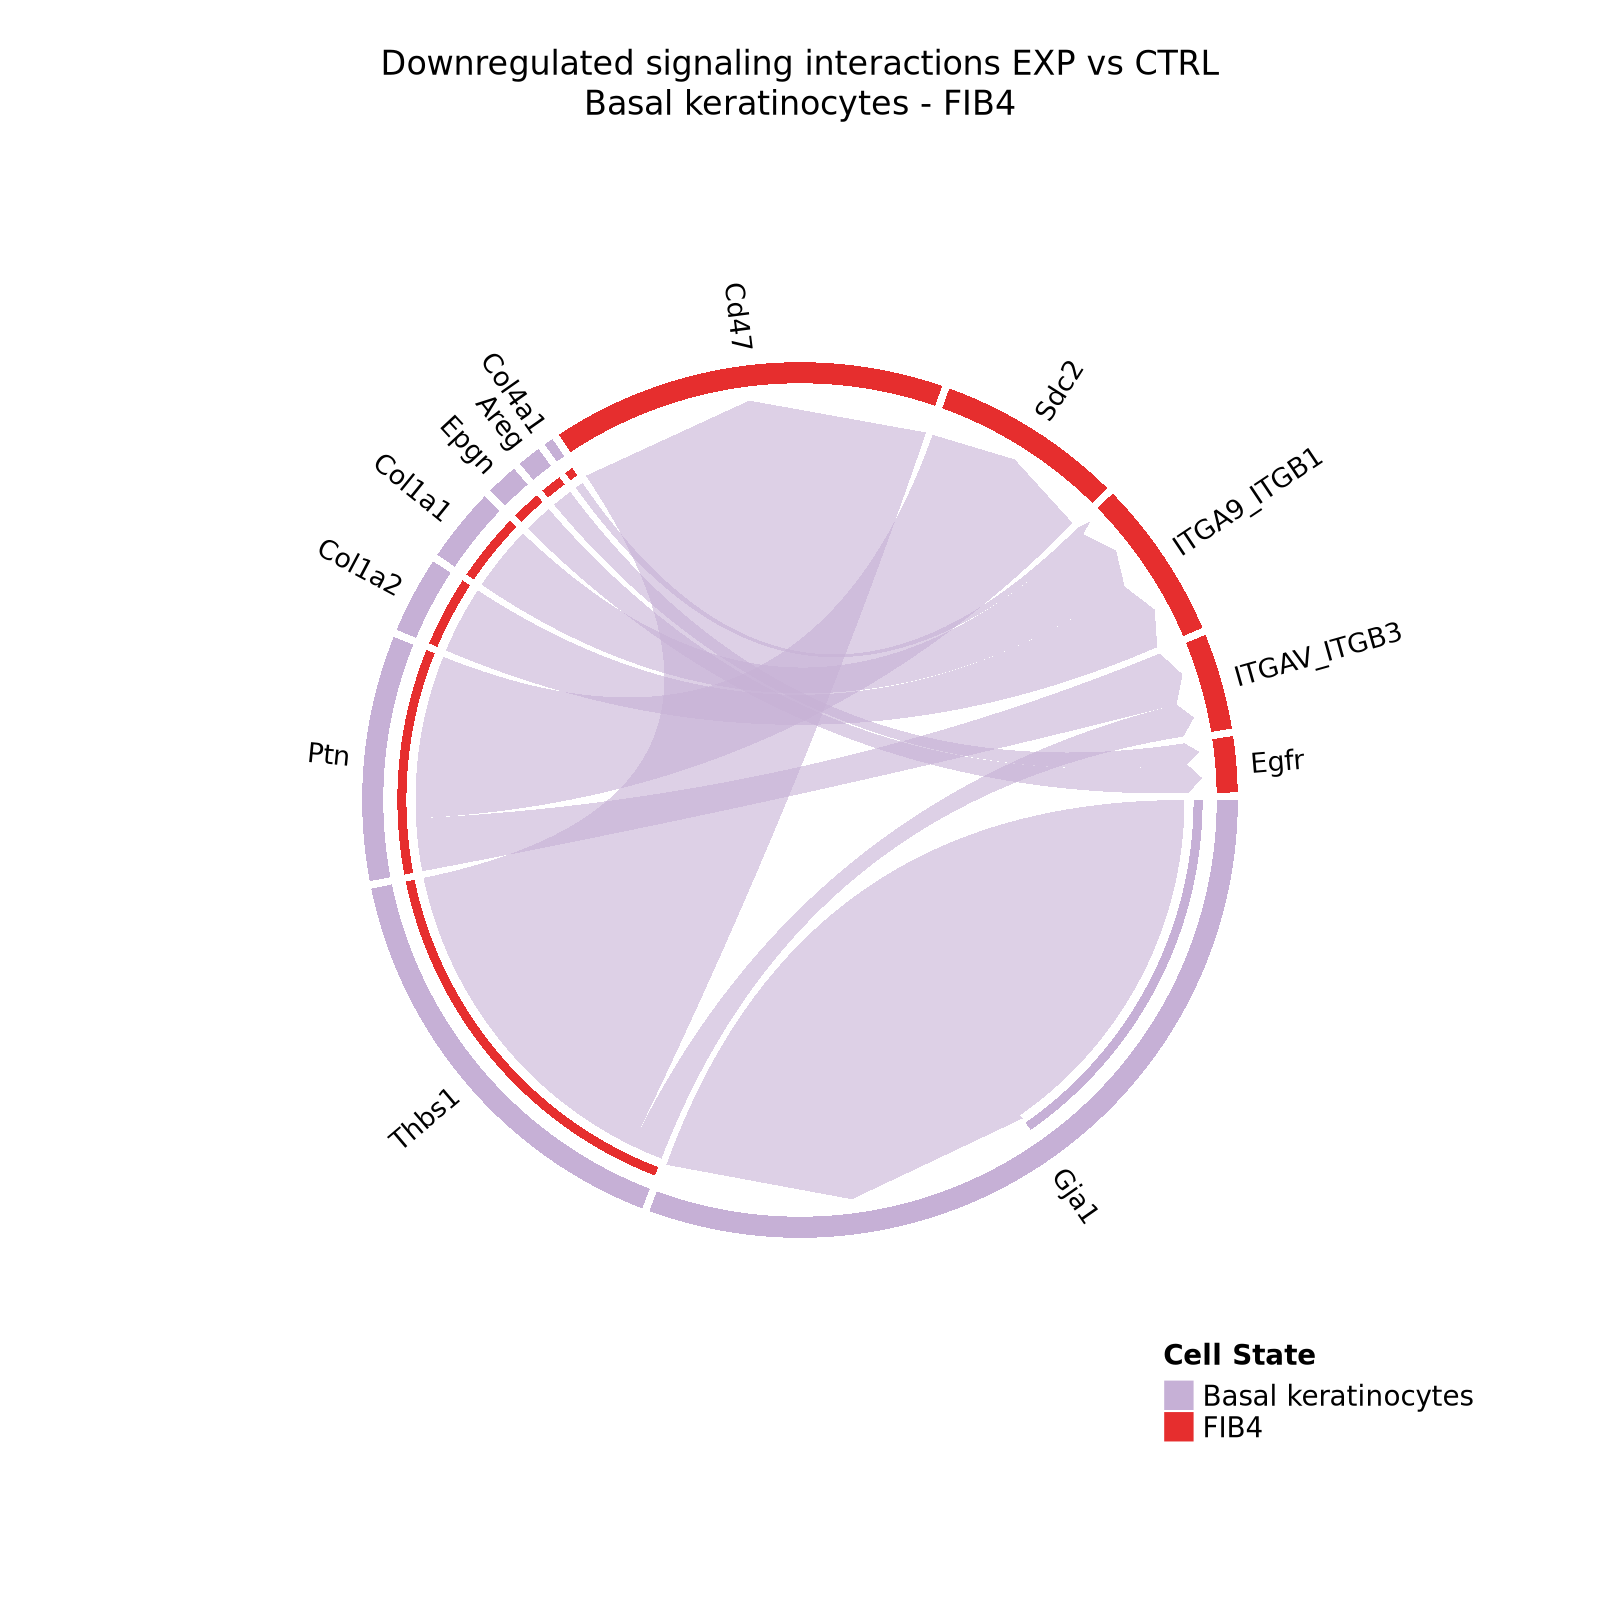

In [9]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

title_b <- 'Downregulated signaling interactions EXP vs CTRL\nBasal keratinocytes - FIB4'

par(bg = 'white')
netVisual_chord_gene(
    object.list[['Control']],
    sources.use = 'Basal keratinocytes',
    targets.use = 'FIB4',
    slot.name   = 'net',
    net         = net.down,
    color.use   = color_use,
    lab.cex     = 0.8,
    small.gap   = 3.5,
    title.name  = title_b
)

draw_chord(
    cc        = object.list[['Control']],
    net_df    = net.down,
    sources   = 'Basal keratinocytes',
    targets   = 'FIB4',
    title     = title_b,
    out_svg   = 'fig7b_downregulated_basal_to_fib4.svg'
)

### Panel c — Upregulated EXP vs CTRL, FIB4 → Basal keratinocytes

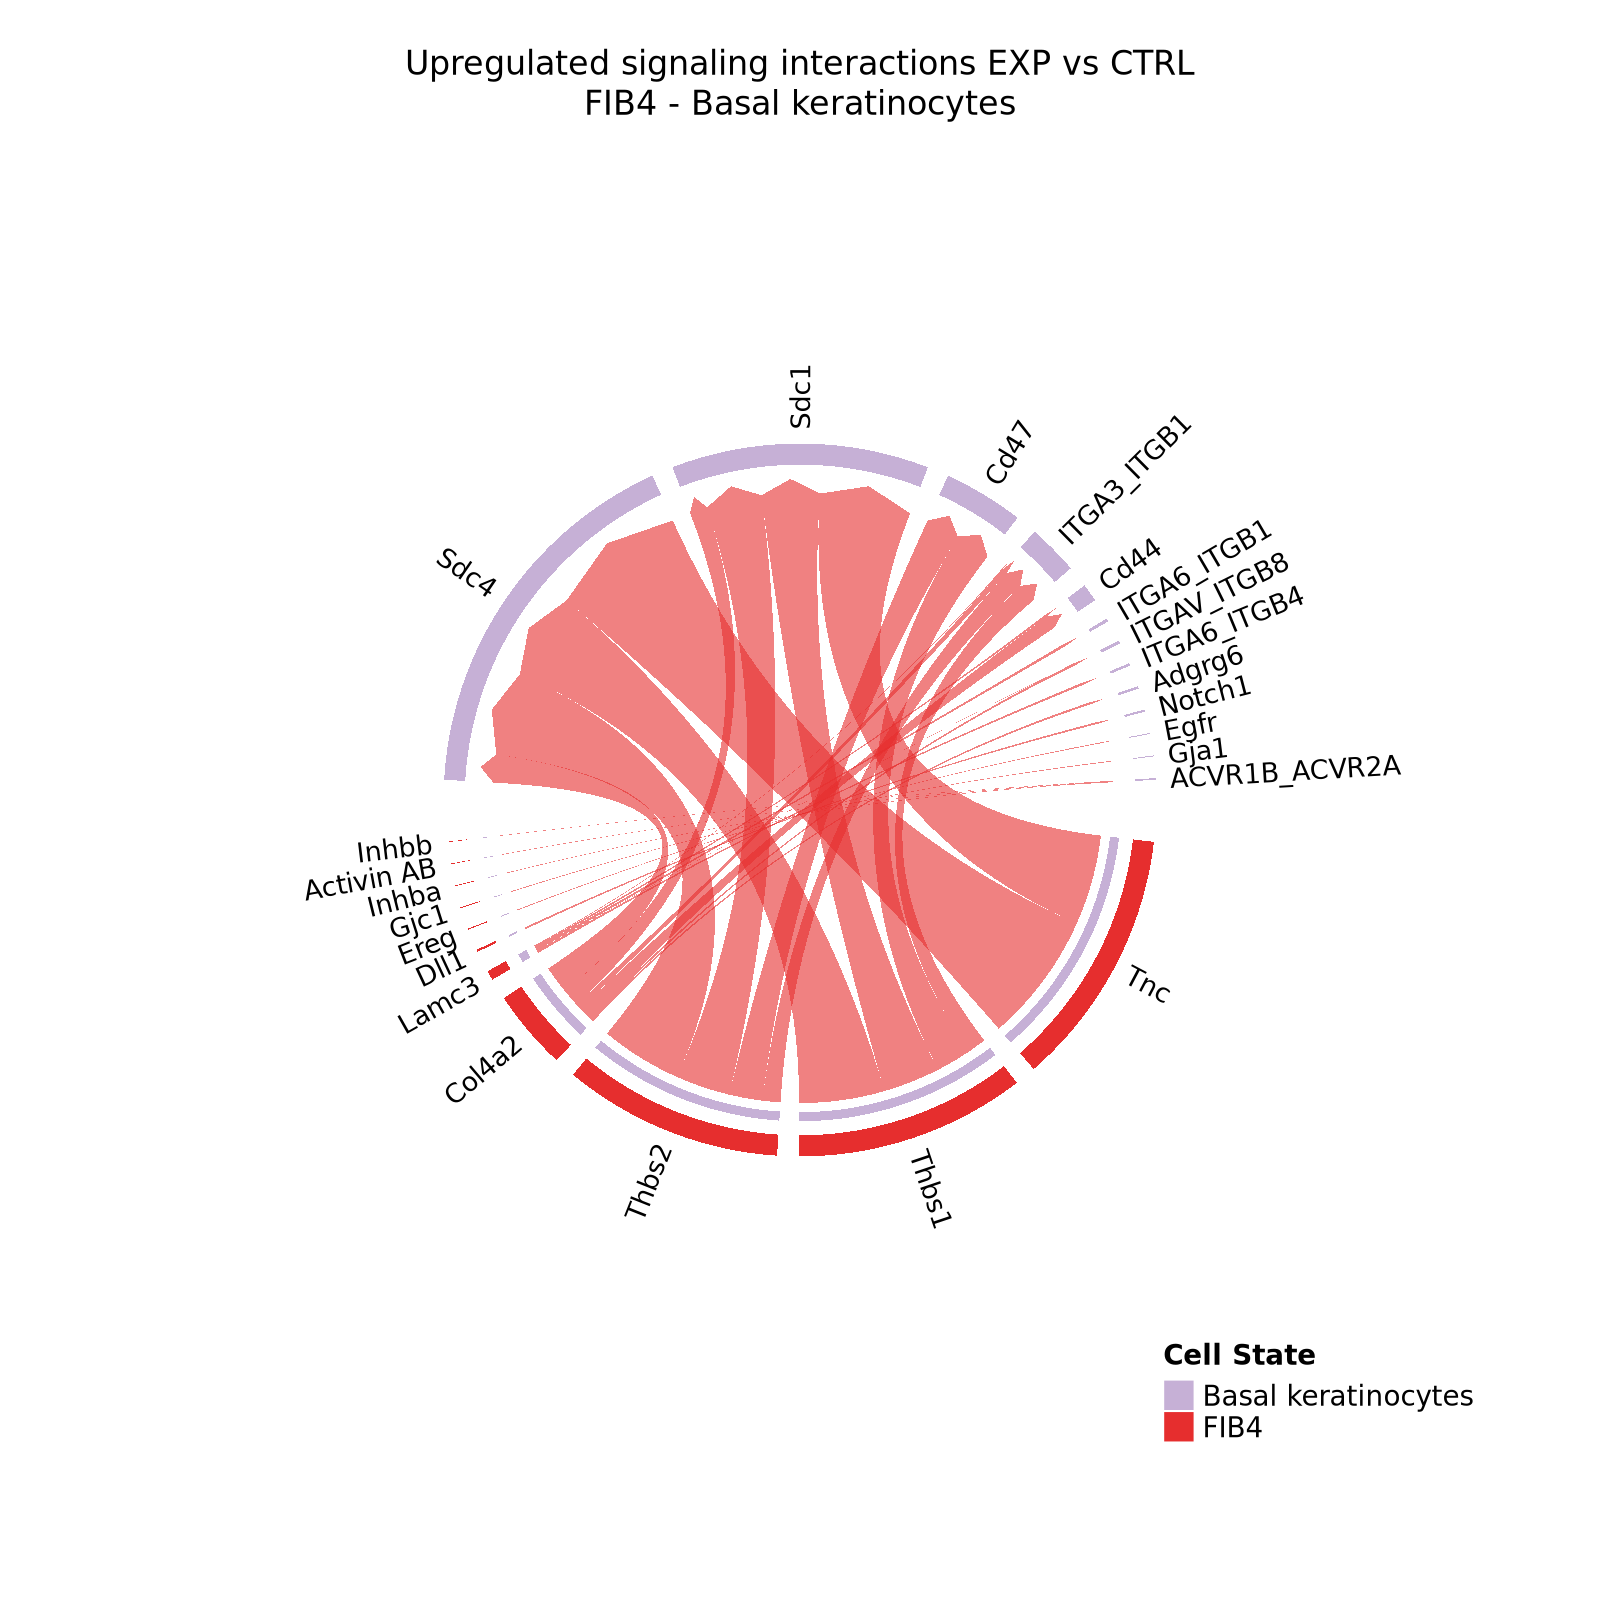

Saved: manuscript_figures/figure_7/fig7c_upregulated_fib4_to_basal.svg



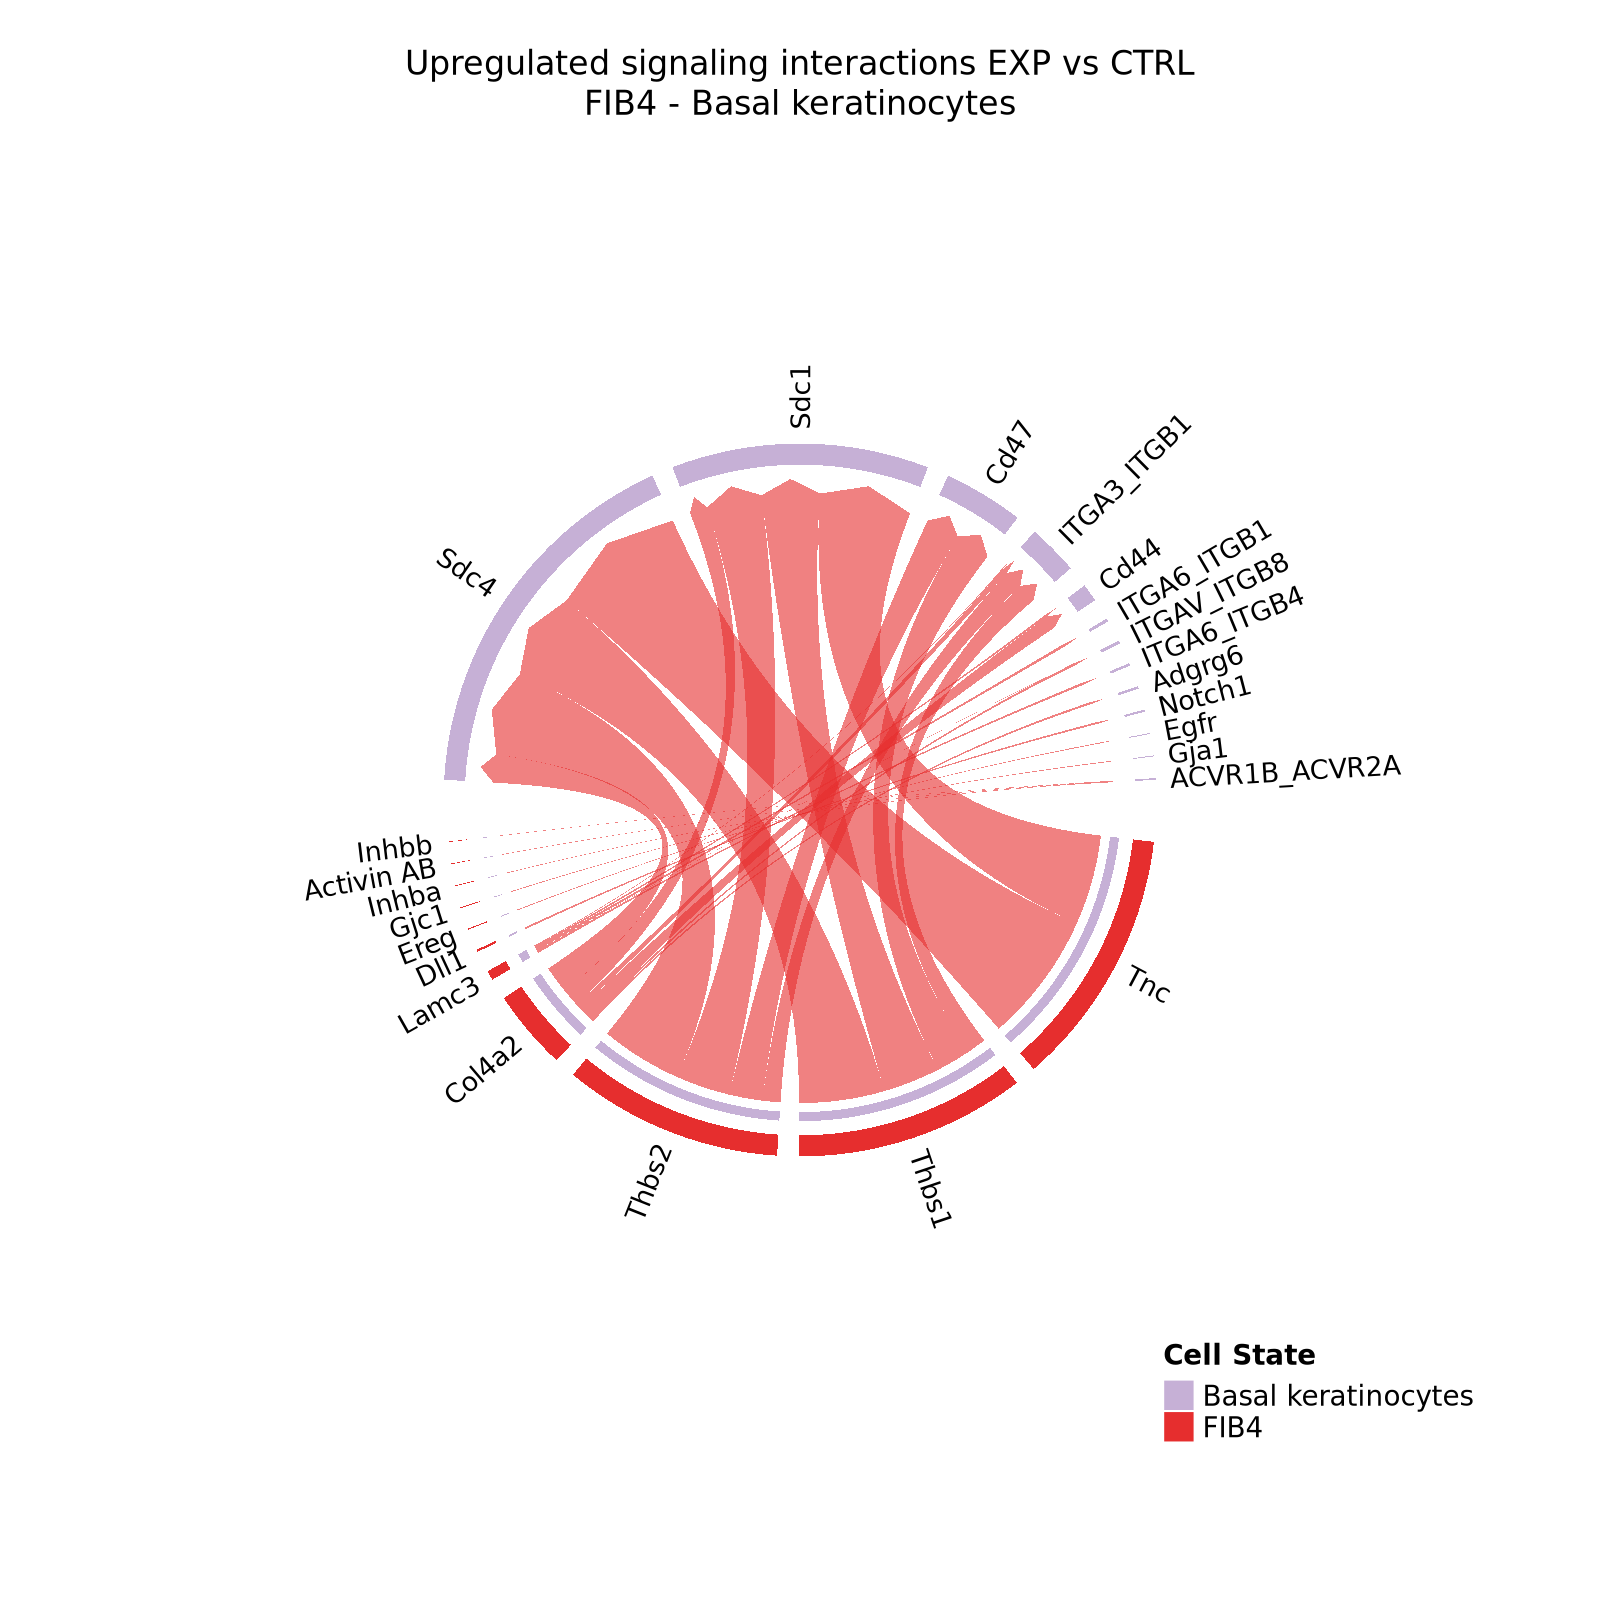

In [10]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

title_c <- 'Upregulated signaling interactions EXP vs CTRL\nFIB4 - Basal keratinocytes'

par(bg = 'white')
netVisual_chord_gene(
    object.list[['Expanded']],
    sources.use = 'FIB4',
    targets.use = 'Basal keratinocytes',
    slot.name   = 'net',
    net         = net.up,
    color.use   = color_use,
    lab.cex     = 0.8,
    small.gap   = 3.5,
    title.name  = title_c
)

draw_chord(
    cc        = object.list[['Expanded']],
    net_df    = net.up,
    sources   = 'FIB4',
    targets   = 'Basal keratinocytes',
    title     = title_c,
    out_svg   = 'fig7c_upregulated_fib4_to_basal.svg'
)

### Panel d — Downregulated EXP vs CTRL, FIB4 → Basal keratinocytes

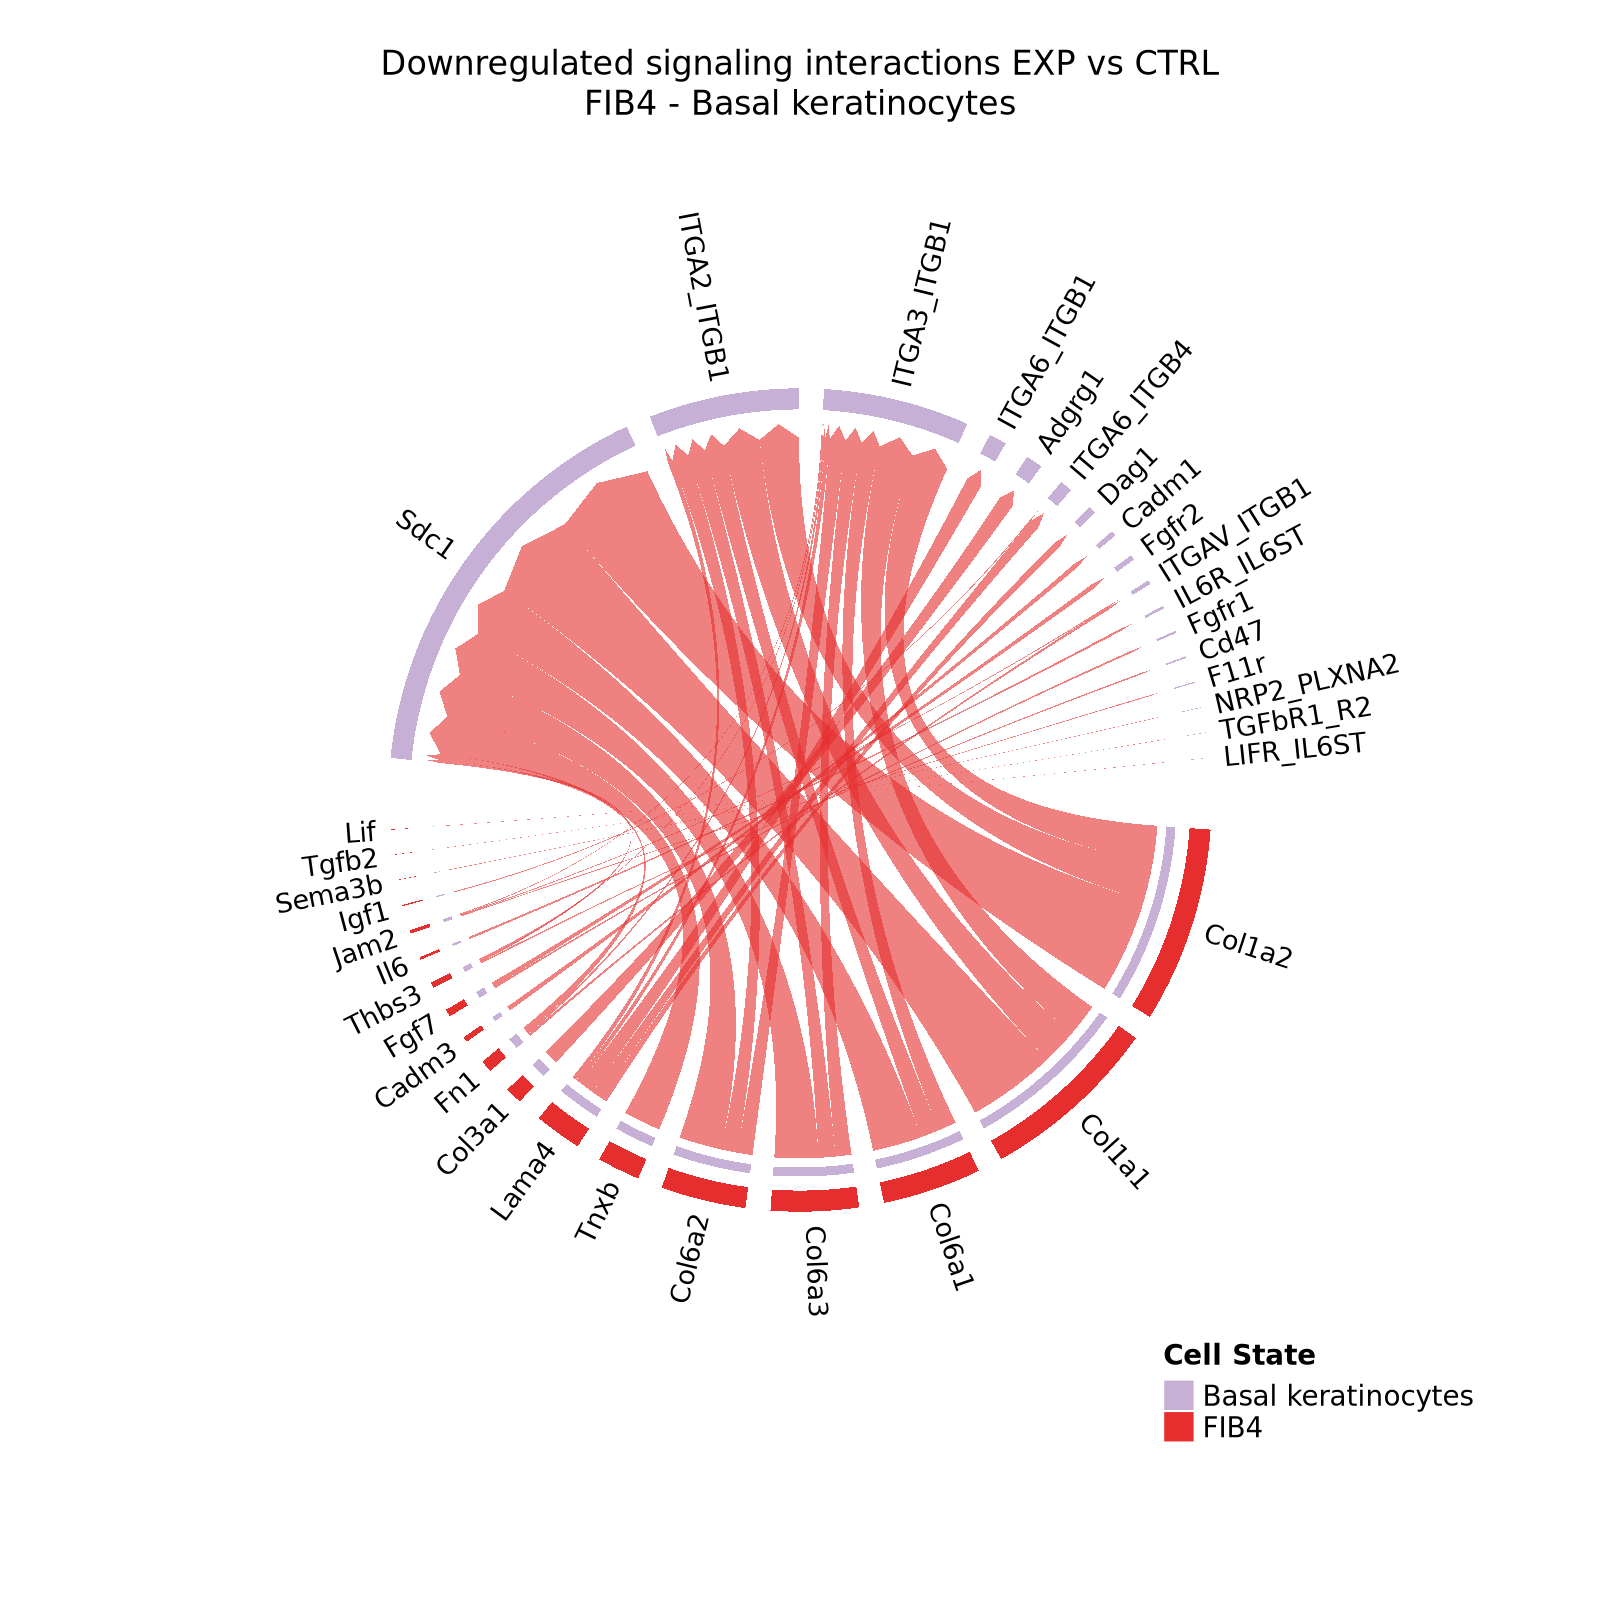

Saved: manuscript_figures/figure_7/fig7d_downregulated_fib4_to_basal.svg



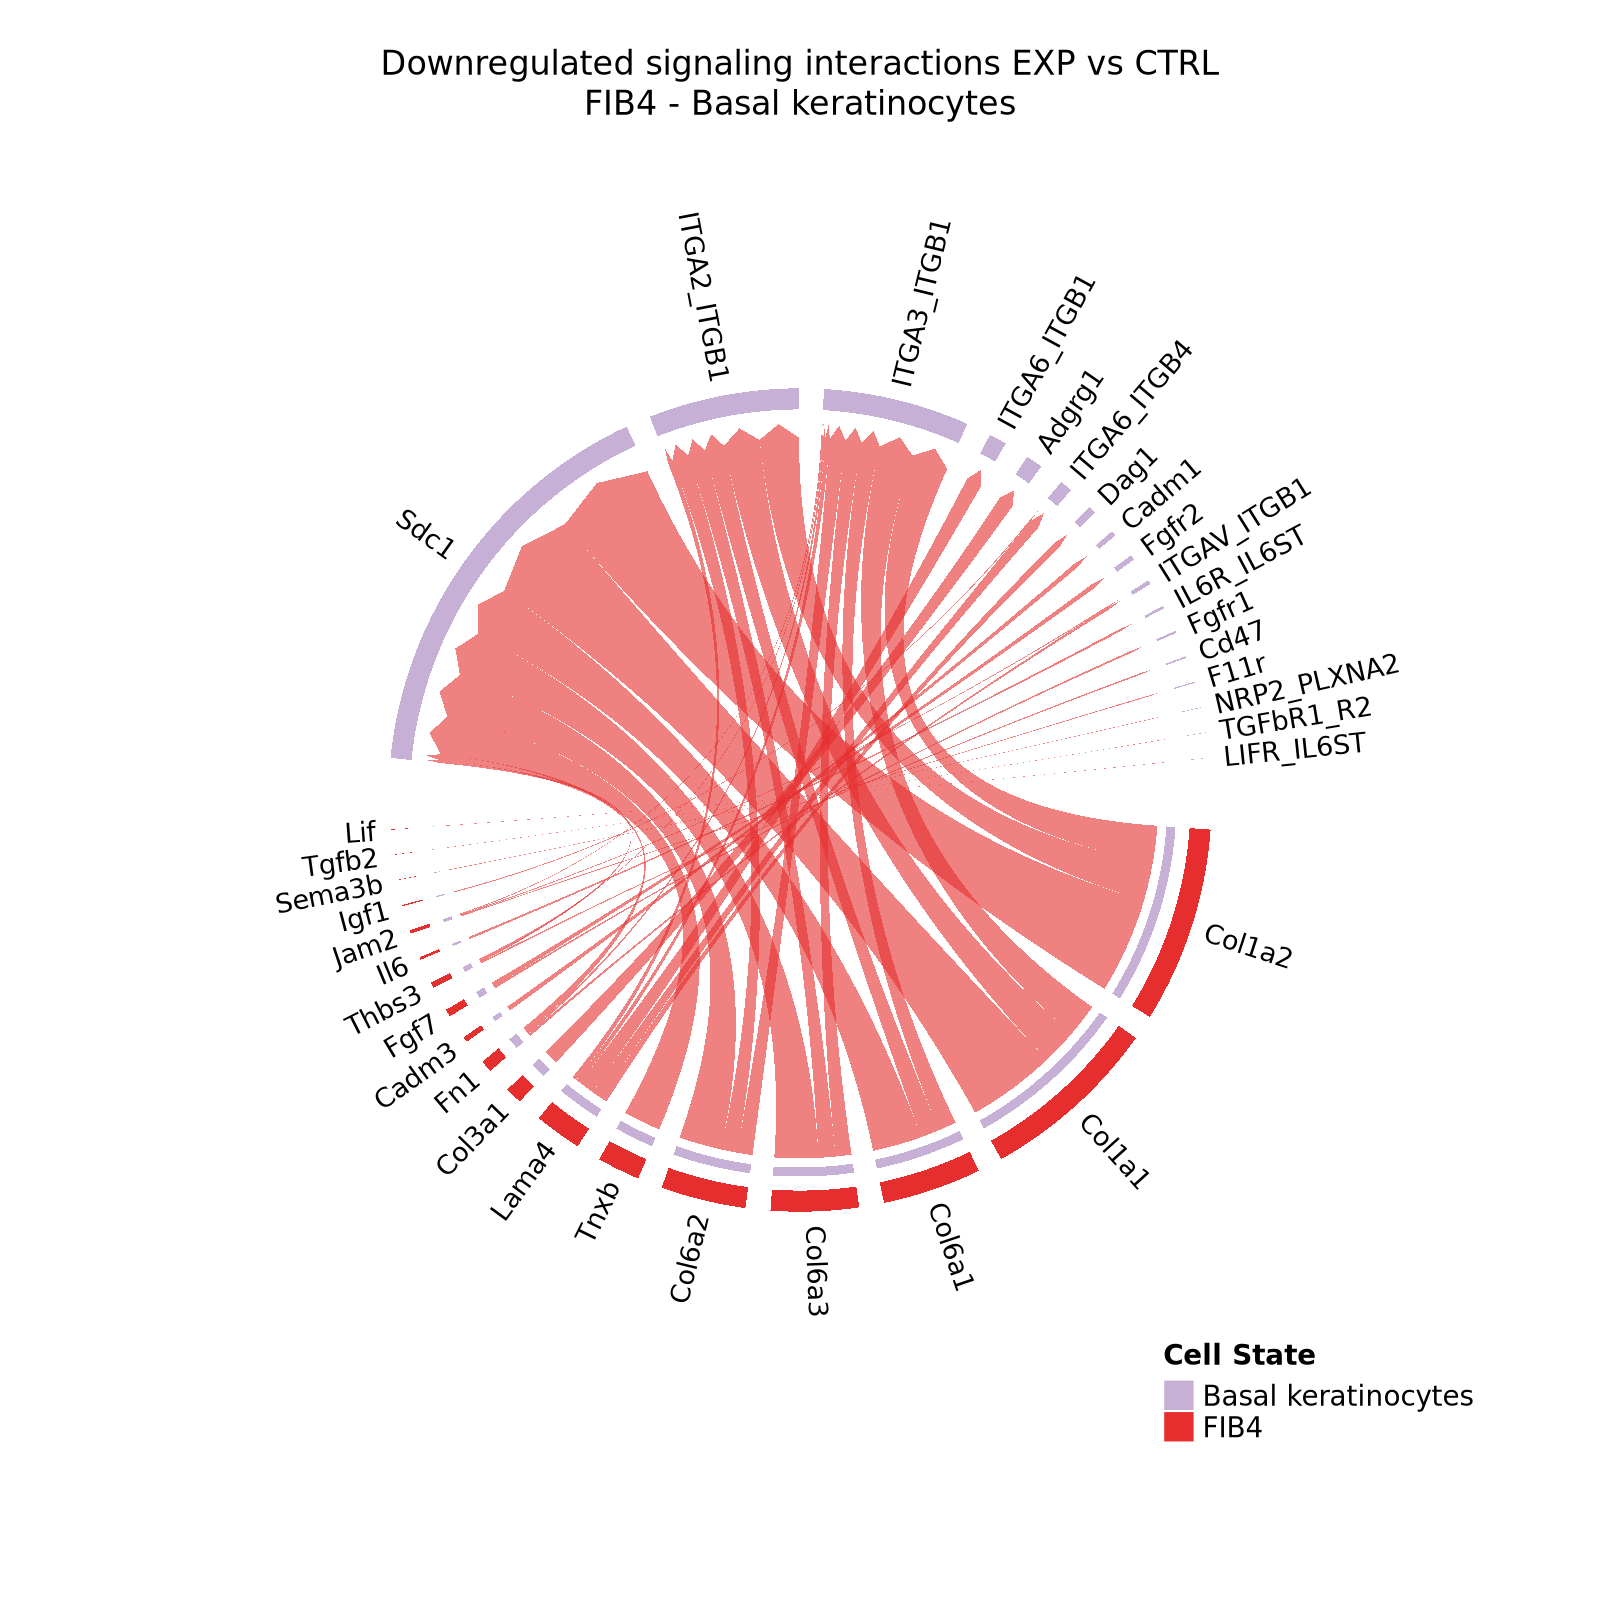

In [11]:
options(repr.plot.width = 8, repr.plot.height = 8, repr.plot.res = 200)

title_d <- 'Downregulated signaling interactions EXP vs CTRL\nFIB4 - Basal keratinocytes'

par(bg = 'white')
netVisual_chord_gene(
    object.list[['Control']],
    sources.use = 'FIB4',
    targets.use = 'Basal keratinocytes',
    slot.name   = 'net',
    net         = net.down,
    color.use   = color_use,
    lab.cex     = 0.8,
    small.gap   = 3.5,
    title.name  = title_d
)

draw_chord(
    cc        = object.list[['Control']],
    net_df    = net.down,
    sources   = 'FIB4',
    targets   = 'Basal keratinocytes',
    title     = title_d,
    out_svg   = 'fig7d_downregulated_fib4_to_basal.svg'
)

---

All four SVGs (`fig7a_*`, `fig7b_*`, `fig7c_*`, `fig7d_*`) and the two source-data CSVs
(`fig7_net_up_for_chord.csv`, `fig7_net_down_for_chord.csv`) are saved to
`../manuscript_figures/figure_7/`. Composite the four panels in Illustrator at the
manuscript layout (2 rows × 2 columns).